# NPZ to PNG Conversion
Convert NPZ files to PNG format while preserving quality

In [1]:
import numpy as np
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Paths
npz_source_folder = '/raid/mpsych/OMAMA/DATA/data/2d_resized_512/images'
png_output_folder = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original'

print(f"Source NPZ folder: {npz_source_folder}")
print(f"Output PNG folder: {png_output_folder}")

Source NPZ folder: /raid/mpsych/OMAMA/DATA/data/2d_resized_512/images
Output PNG folder: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original


In [3]:
# CLEANUP: Delete old converted images first
import shutil

if os.path.exists(png_output_folder):
    print(f"Cleaning up old converted images from: {png_output_folder}")
    shutil.rmtree(png_output_folder)
    print("✅ Old images deleted!")

# Create fresh output folder
os.makedirs(png_output_folder, exist_ok=True)
print(f"✅ Created fresh output folder: {png_output_folder}")


Cleaning up old converted images from: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original
✅ Old images deleted!
✅ Created fresh output folder: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original


In [4]:
# Create output folder
os.makedirs(png_output_folder, exist_ok=True)
print(f"Created output folder: {png_output_folder}")

Created output folder: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original


In [5]:
# Option A: Adaptive Window/Level (preserves detail better)
def apply_window_level(image, window_center=None, window_width=None):
    image = image.astype(np.float32)
    
    # Use adaptive window/level based on image statistics
    if window_center is None or window_width is None:
        # Calculate adaptive window/level to preserve detail
        mean_val = image.mean()
        std_val = image.std()
        window_center = mean_val
        window_width = std_val * 6  # Wider window to preserve detail
    
    window_min = window_center - window_width / 2
    window_max = window_center + window_width / 2
    
    # Apply window/level
    image = np.clip(image, window_min, window_max)
    
    # Normalize to 0-255 preserving relative contrast
    image = (image - window_min) / (window_max - window_min) * 255.0
    image = image.astype(np.uint8)
    
    return image

# Option B: Keep raw values (MAXIMUM quality preservation)
def keep_raw_values(image):
    """Convert NPZ to PNG keeping original values - best quality"""
    image = image.astype(np.float32)
    
    # Normalize to 0-255 range without window/level
    min_val = image.min()
    max_val = image.max()
    
    if max_val > min_val:
        image = (image - min_val) / (max_val - min_val) * 255.0
    else:
        image = np.zeros_like(image)
    
    image = image.astype(np.uint8)
    return image

In [6]:
# Get ALL NPZ files for conversion
npz_files = [f for f in os.listdir(npz_source_folder) if f.endswith('.npz')]
print(f"Total NPZ files: {len(npz_files)}")

# Convert ALL files now that quality is verified
npz_files_to_convert = npz_files
print(f"Converting ALL {len(npz_files_to_convert)} files")

Total NPZ files: 163568
Converting ALL 163568 files


In [7]:
# Conversion loop - USING OPTION B FOR BEST QUALITY
for npz_filename in tqdm(npz_files_to_convert):
    npz_path = os.path.join(npz_source_folder, npz_filename)
    with np.load(npz_path, allow_pickle=True) as data:
        npz_image = data['data']
    
    # Use Option B: Keep raw values for maximum quality
    png_image = keep_raw_values(npz_image)
    png_filename = npz_filename.replace('.npz', '.png')
    png_path = os.path.join(png_output_folder, png_filename)
    cv2.imwrite(png_path, png_image, [cv2.IMWRITE_PNG_COMPRESSION, 0])

print(f"Conversion complete! Converted {len(npz_files_to_convert)} files with MAXIMUM quality")

 ... (more hidden) ...

Conversion complete! Converted 163568 files with MAXIMUM quality


## Verification: Compare NPZ vs PNG

=== FINAL QUALITY CHECK ===
Showing multiple NPZ vs PNG comparisons...
Total converted PNG files: 163568


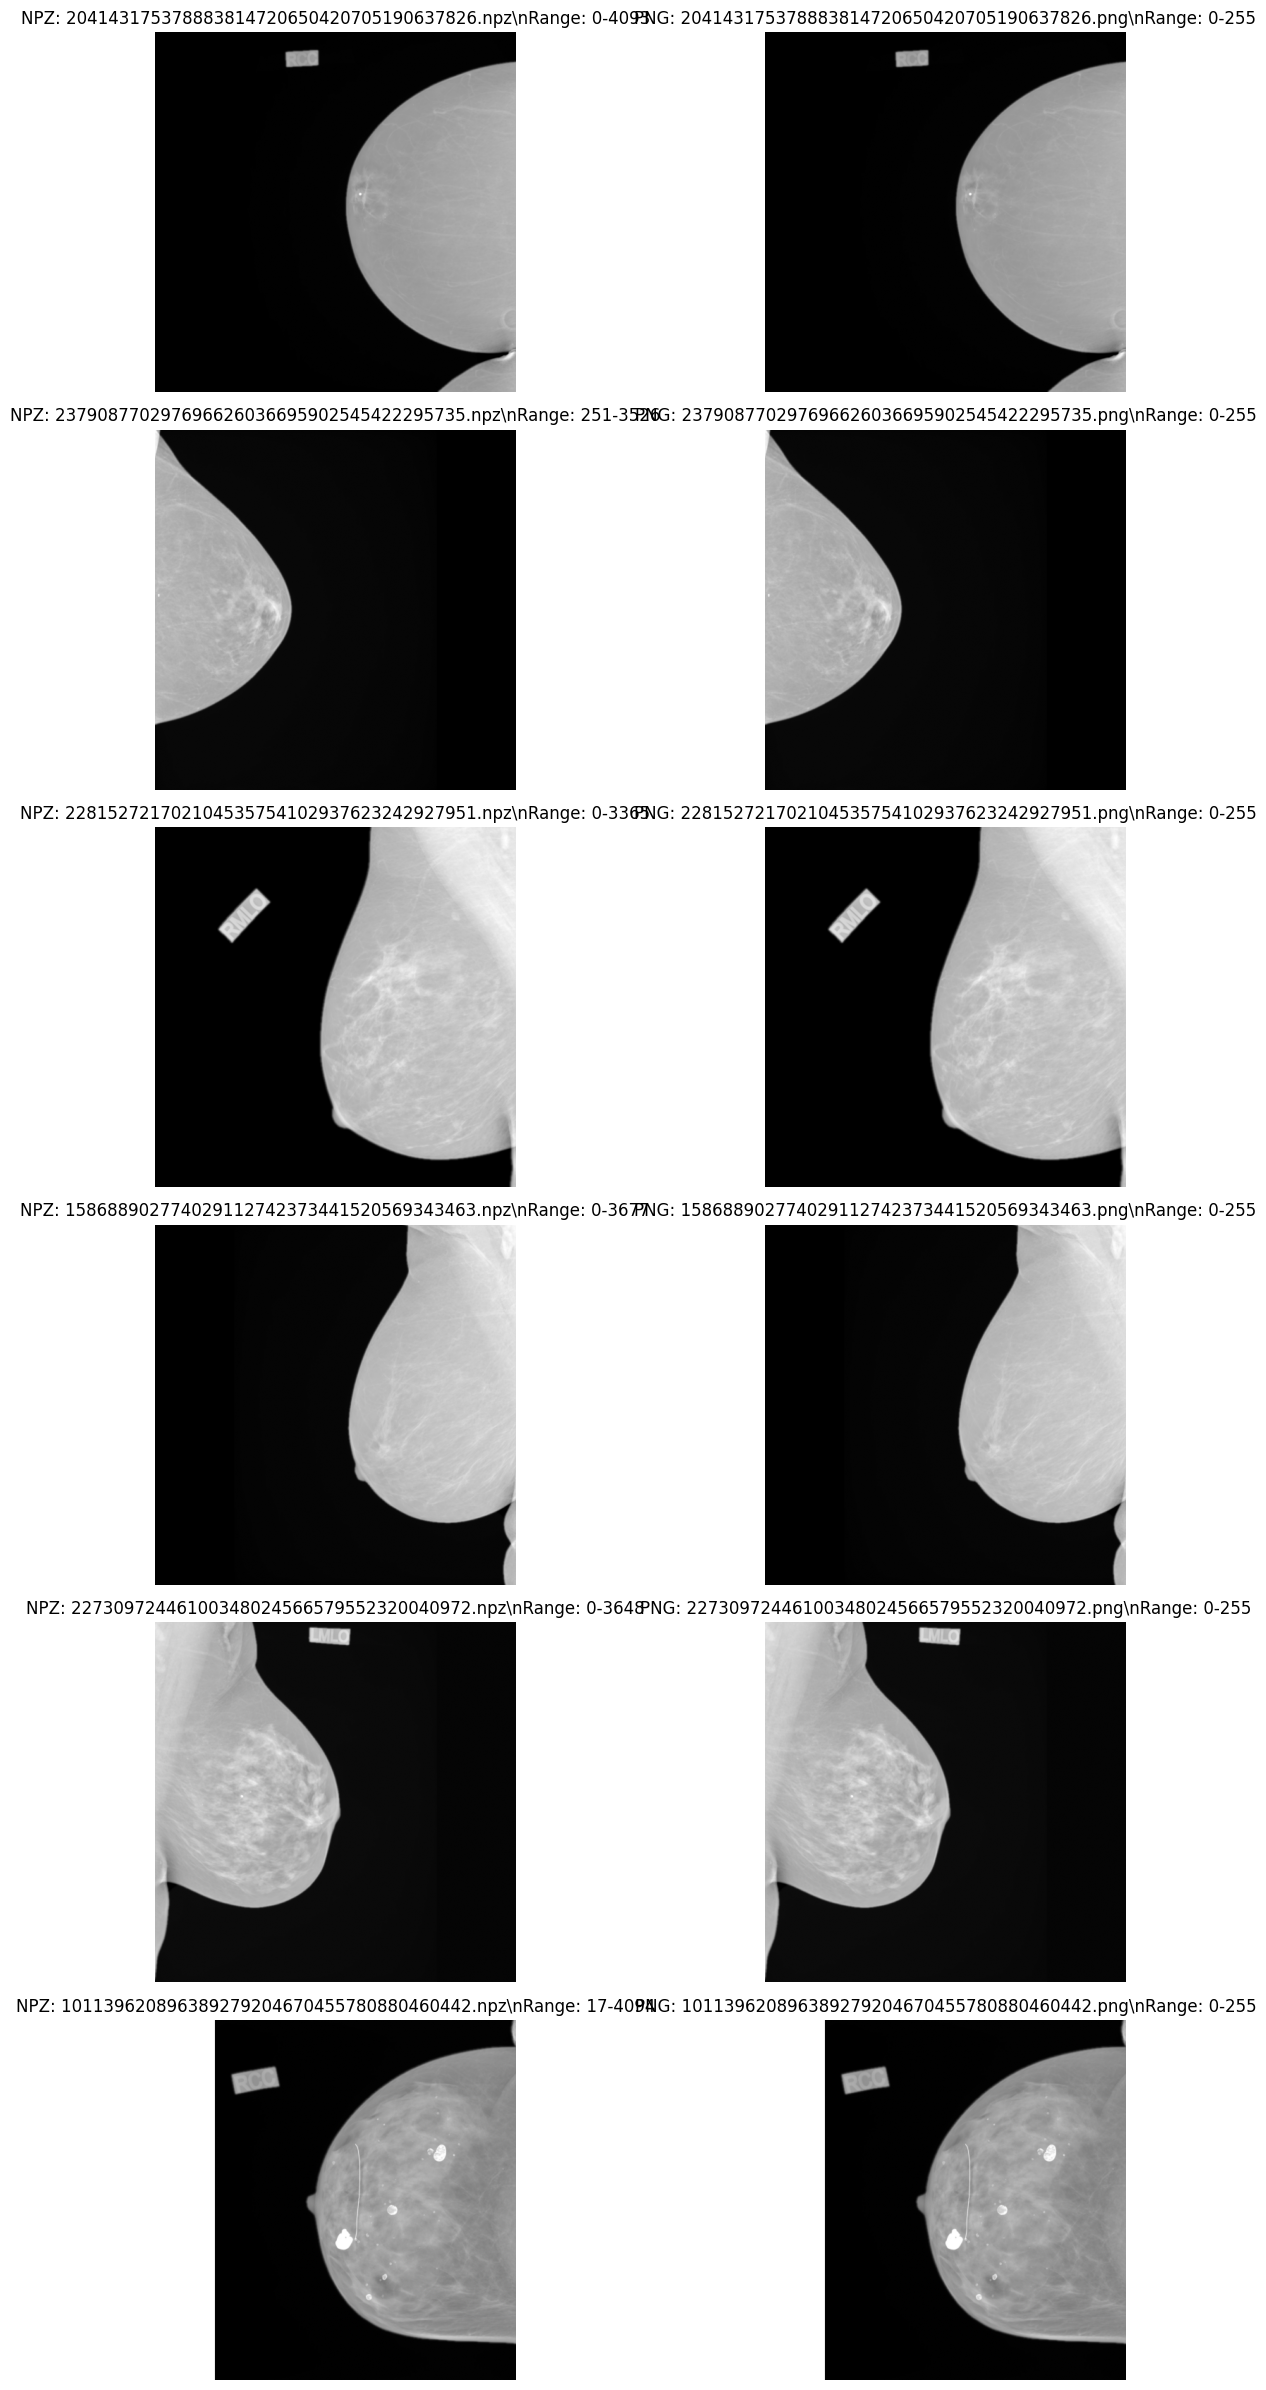

\n✅ Quality verification complete!
All images should look identical with preserved detail!


In [8]:
# FINAL VERIFICATION: Show multiple converted images side-by-side
print("=== FINAL QUALITY CHECK ===")
print("Showing multiple NPZ vs PNG comparisons...")

# Get all converted PNG files
converted_png_files = [f for f in os.listdir(png_output_folder) if f.endswith('.png')]
print(f"Total converted PNG files: {len(converted_png_files)}")

# Show 6 random comparisons
import random
random.seed(42)  # For reproducible results

num_comparisons = min(6, len(converted_png_files))
sample_files = random.sample(converted_png_files, num_comparisons)

fig, axes = plt.subplots(num_comparisons, 2, figsize=(15, 4*num_comparisons))

if num_comparisons == 1:
    axes = axes.reshape(1, -1)

for i, png_filename in enumerate(sample_files):
    # Get corresponding NPZ filename
    npz_filename = png_filename.replace('.png', '.npz')
    
    # Load NPZ
    npz_path = os.path.join(npz_source_folder, npz_filename)
    with np.load(npz_path, allow_pickle=True) as data:
        npz_img = data['data']
    
    # Load PNG
    png_path = os.path.join(png_output_folder, png_filename)
    png_img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    
    # Display NPZ
    axes[i, 0].imshow(npz_img, cmap='gray')
    axes[i, 0].set_title(f'NPZ: {npz_filename}\\nRange: {npz_img.min():.0f}-{npz_img.max():.0f}')
    axes[i, 0].axis('off')
    
    # Display PNG
    axes[i, 1].imshow(png_img, cmap='gray')
    axes[i, 1].set_title(f'PNG: {png_filename}\\nRange: {png_img.min()}-{png_img.max()}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print("\\n✅ Quality verification complete!")
print("All images should look identical with preserved detail!")


Comparing: 267934773880390363402441981338430720492.npz


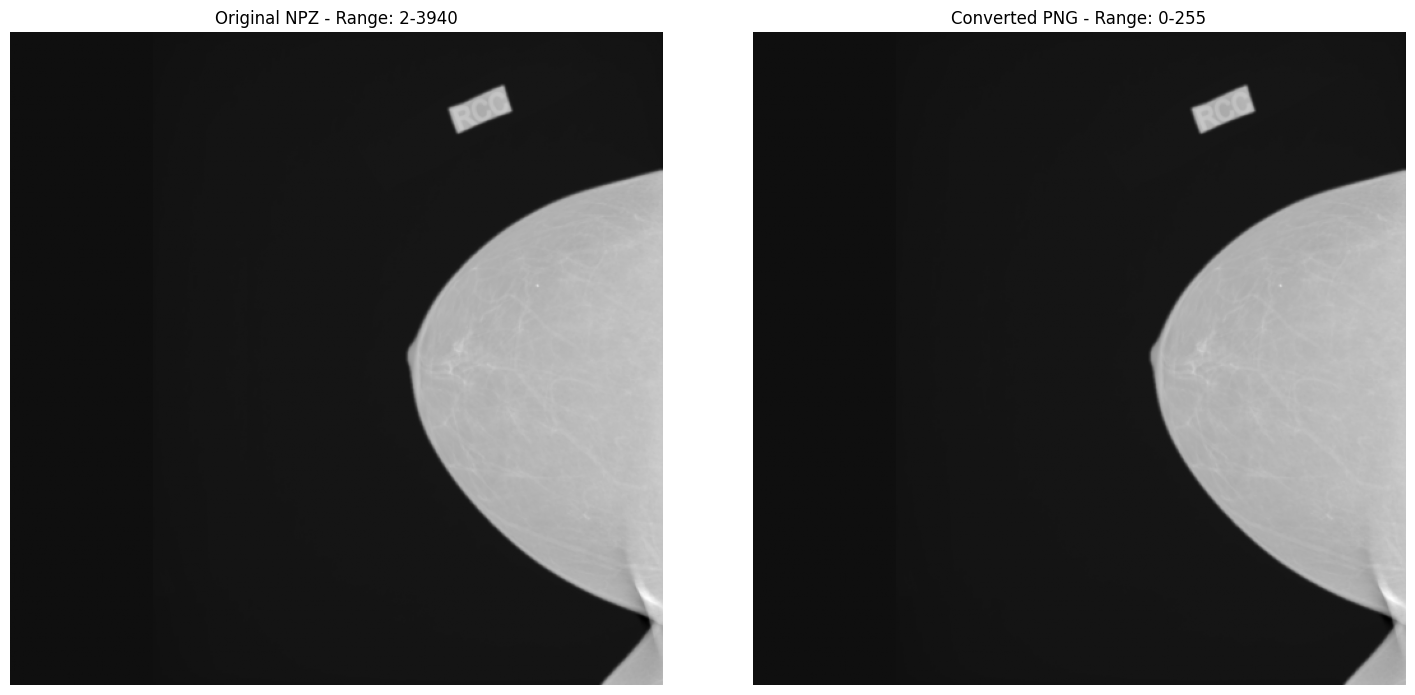

Original shape: (512, 512)
Converted shape: (512, 512)
Quality preserved: True


In [9]:
# Visual comparison
test_filename = npz_files_to_convert[0]
print(f"Comparing: {test_filename}")

# Load original NPZ
npz_path = os.path.join(npz_source_folder, test_filename)
with np.load(npz_path, allow_pickle=True) as data:
    original_npz = data['data']

# Load converted PNG
png_filename = test_filename.replace('.npz', '.png')
png_path = os.path.join(png_output_folder, png_filename)
converted_png = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(original_npz, cmap='gray')
axes[0].set_title(f'Original NPZ - Range: {original_npz.min():.0f}-{original_npz.max():.0f}')
axes[0].axis('off')
axes[1].imshow(converted_png, cmap='gray')
axes[1].set_title(f'Converted PNG - Range: {converted_png.min()}-{converted_png.max()}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Original shape: {original_npz.shape}")
print(f"Converted shape: {converted_png.shape}")
print(f"Quality preserved: {original_npz.shape == converted_png.shape}")

## Visual Comparison: Synthetic vs Original Mammograms


In [2]:
# Compare synthetic (from /raid) vs original (converted PNG) side by side
import random
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
synthetic_path = '/raid/mpsych/OMAMA/DATA/data/train'
original_converted_path = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original'

# Get random samples
synthetic_files = glob.glob(os.path.join(synthetic_path, '*.png'))
original_files = glob.glob(os.path.join(original_converted_path, '*.png'))

# Select 2 random images from each
random.seed(42)
synthetic_samples = random.sample(synthetic_files, 2)
original_samples = random.sample(original_files, 2)

print(f"Total synthetic files: {len(synthetic_files)}")
print(f"Total original files: {len(original_files)}")
print(f"\nSelected synthetic samples:")
for f in synthetic_samples:
    print(f"  - {os.path.basename(f)}")
print(f"\nSelected original samples:")
for f in original_samples:
    print(f"  - {os.path.basename(f)}")


Total synthetic files: 99999
Total original files: 163568

Selected synthetic samples:
  - sample_94656.png
  - sample_10422.png

Selected original samples:
  - 237908770297696626036695902545422295735.png
  - 228152721702104535754102937623242927951.png


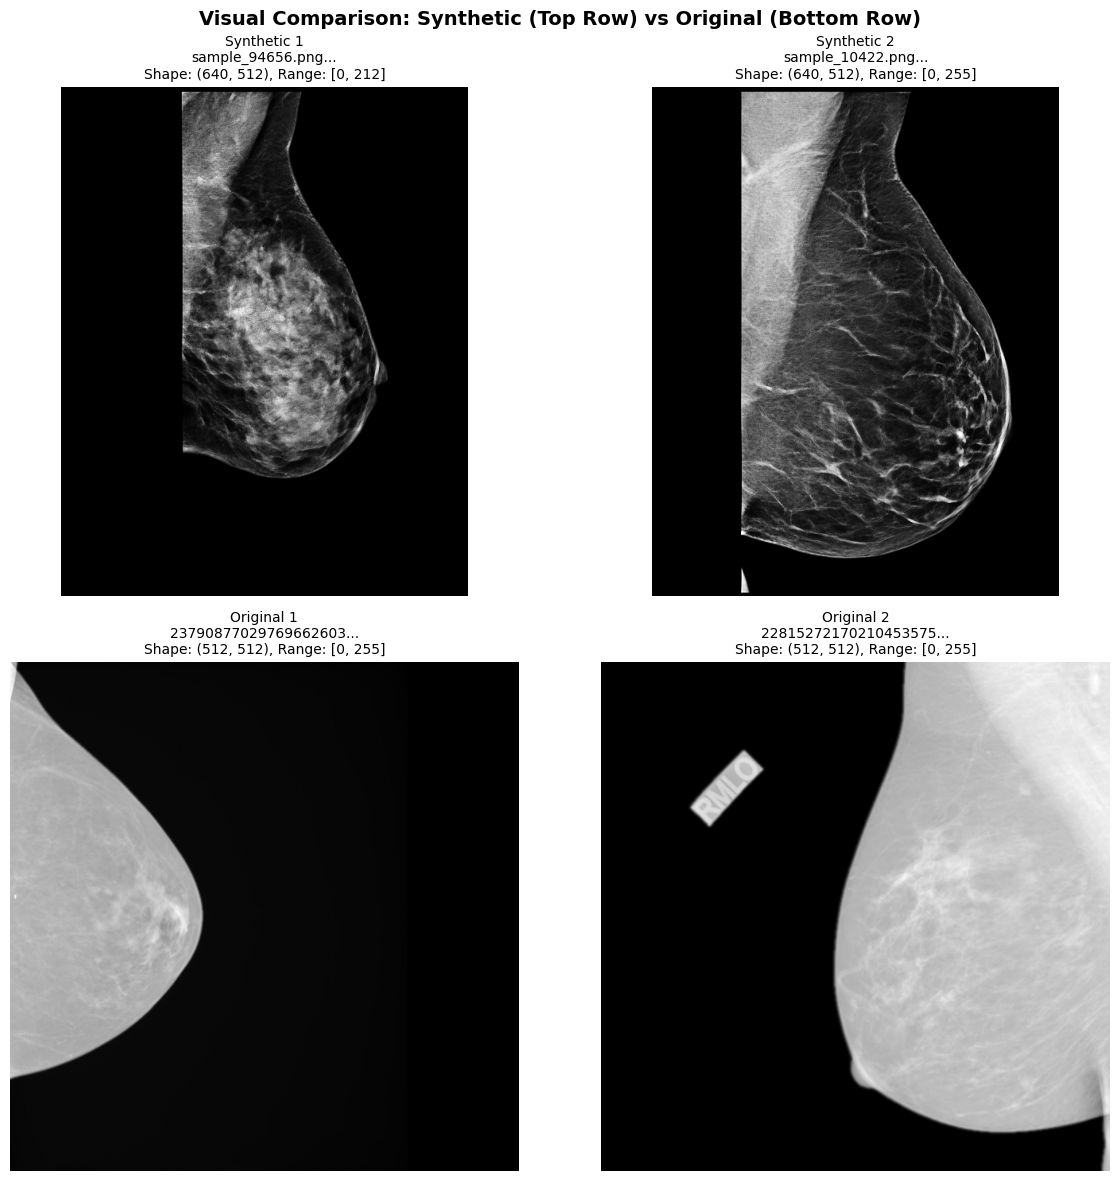

In [3]:
# Load and display the images side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Load synthetic images
for idx, img_path in enumerate(synthetic_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Synthetic {idx+1}\n{os.path.basename(img_path)[:20]}...\nShape: {img.shape}, Range: [{img.min()}, {img.max()}]', 
                          fontsize=10)
    axes[0, idx].axis('off')

# Load original images
for idx, img_path in enumerate(original_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[1, idx].imshow(img, cmap='gray')
    axes[1, idx].set_title(f'Original {idx+1}\n{os.path.basename(img_path)[:20]}...\nShape: {img.shape}, Range: [{img.min()}, {img.max()}]', 
                          fontsize=10)
    axes[1, idx].axis('off')

plt.suptitle('Visual Comparison: Synthetic (Top Row) vs Original (Bottom Row)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [4]:
# Detailed analysis: Check for systematic differences
print("DETAILED IMAGE ANALYSIS:")
print("=" * 60)

# Analyze synthetic images
print("\nSYNTHETIC IMAGES:")
for idx, img_path in enumerate(synthetic_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    file_size = os.path.getsize(img_path) / 1024  # KB
    print(f"\nSample {idx+1}: {os.path.basename(img_path)}")
    print(f"  File size: {file_size:.2f} KB")
    print(f"  Shape: {img.shape}")
    print(f"  Dtype: {img.dtype}")
    print(f"  Range: [{img.min()}, {img.max()}]")
    print(f"  Mean: {img.mean():.2f}")
    print(f"  Std: {img.std():.2f}")

# Analyze original images
print("\nORIGINAL IMAGES (Converted from NPZ):")
for idx, img_path in enumerate(original_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    file_size = os.path.getsize(img_path) / 1024  # KB
    print(f"\nSample {idx+1}: {os.path.basename(img_path)}")
    print(f"  File size: {file_size:.2f} KB")
    print(f"  Shape: {img.shape}")
    print(f"  Dtype: {img.dtype}")
    print(f"  Range: [{img.min()}, {img.max()}]")
    print(f"  Mean: {img.mean():.2f}")
    print(f"  Std: {img.std():.2f}")

print("\n" + "=" * 60)


DETAILED IMAGE ANALYSIS:

SYNTHETIC IMAGES:

Sample 1: sample_94656.png
  File size: 69.18 KB
  Shape: (640, 512)
  Dtype: uint8
  Range: [0, 212]
  Mean: 17.99
  Std: 36.09

Sample 2: sample_10422.png
  File size: 119.90 KB
  Shape: (640, 512)
  Dtype: uint8
  Range: [0, 255]
  Mean: 37.69
  Std: 54.86

ORIGINAL IMAGES (Converted from NPZ):

Sample 1: 237908770297696626036695902545422295735.png
  File size: 256.98 KB
  Shape: (512, 512)
  Dtype: uint8
  Range: [0, 255]
  Mean: 38.20
  Std: 68.07

Sample 2: 228152721702104535754102937623242927951.png
  File size: 256.98 KB
  Shape: (512, 512)
  Dtype: uint8
  Range: [0, 255]
  Mean: 88.65
  Std: 98.81



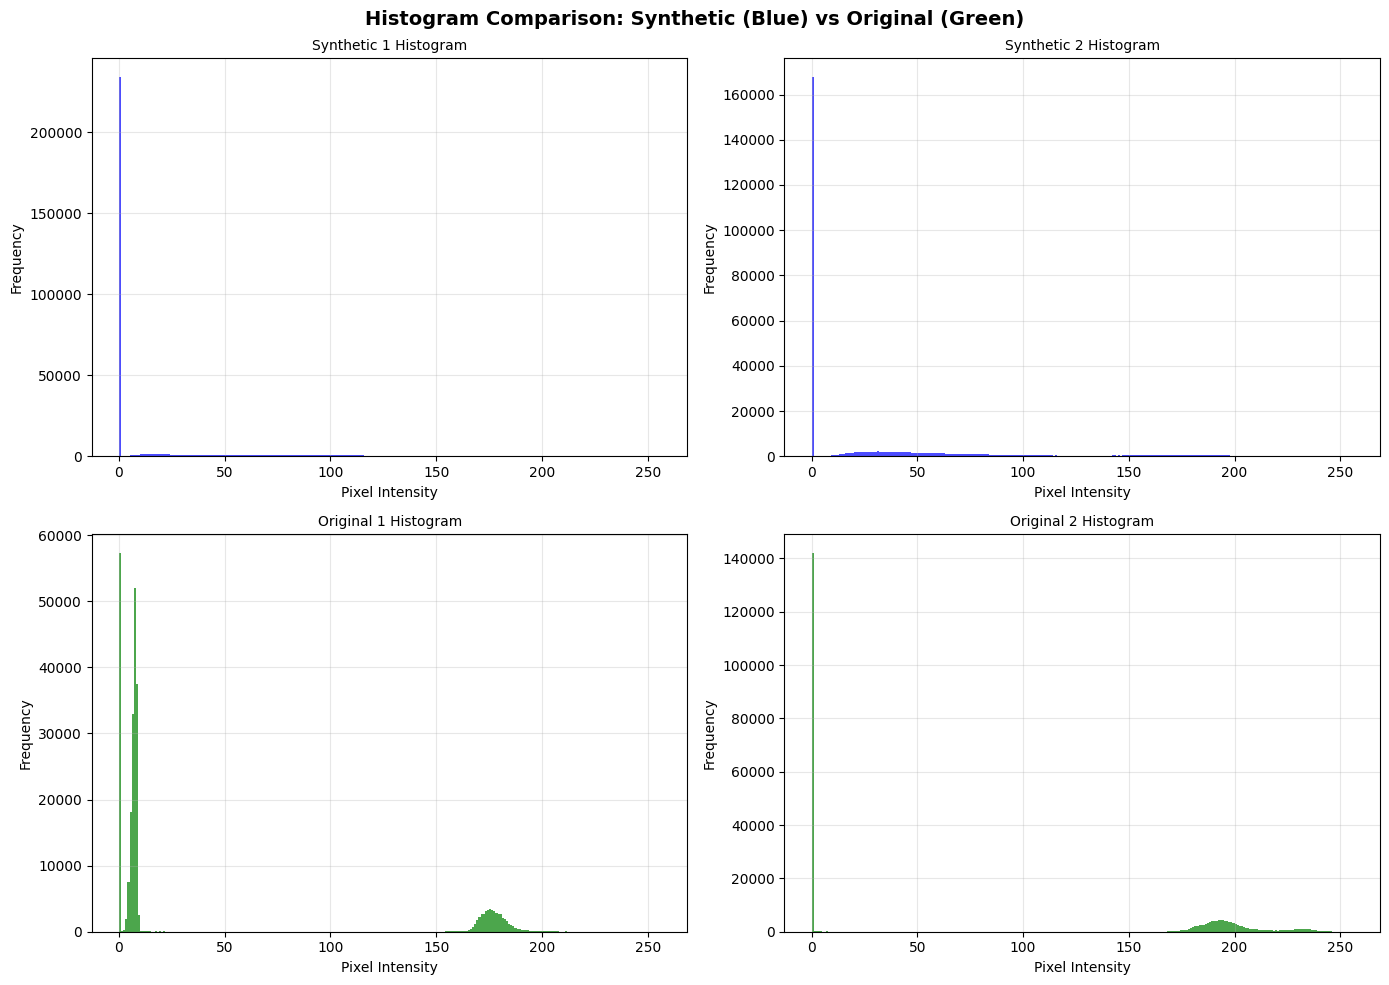

Check if histogram distributions look different between synthetic and original images.


In [5]:
# Check histogram distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Synthetic histograms
for idx, img_path in enumerate(synthetic_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[0, idx].hist(img.ravel(), bins=256, range=(0, 256), alpha=0.7, color='blue')
    axes[0, idx].set_title(f'Synthetic {idx+1} Histogram', fontsize=10)
    axes[0, idx].set_xlabel('Pixel Intensity')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(True, alpha=0.3)

# Original histograms
for idx, img_path in enumerate(original_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[1, idx].hist(img.ravel(), bins=256, range=(0, 256), alpha=0.7, color='green')
    axes[1, idx].set_title(f'Original {idx+1} Histogram', fontsize=10)
    axes[1, idx].set_xlabel('Pixel Intensity')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Histogram Comparison: Synthetic (Blue) vs Original (Green)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Check if histogram distributions look different between synthetic and original images.")


## Comprehensive Comparison: 10 Synthetic vs 10 Original Images


In [6]:
# Select 10 random images from each class
num_samples = 10
random.seed(123)

synthetic_samples_10 = random.sample(synthetic_files, num_samples)
original_samples_10 = random.sample(original_files, num_samples)

print(f"Selected {num_samples} synthetic images")
print(f"Selected {num_samples} original images")


Selected 10 synthetic images
Selected 10 original images


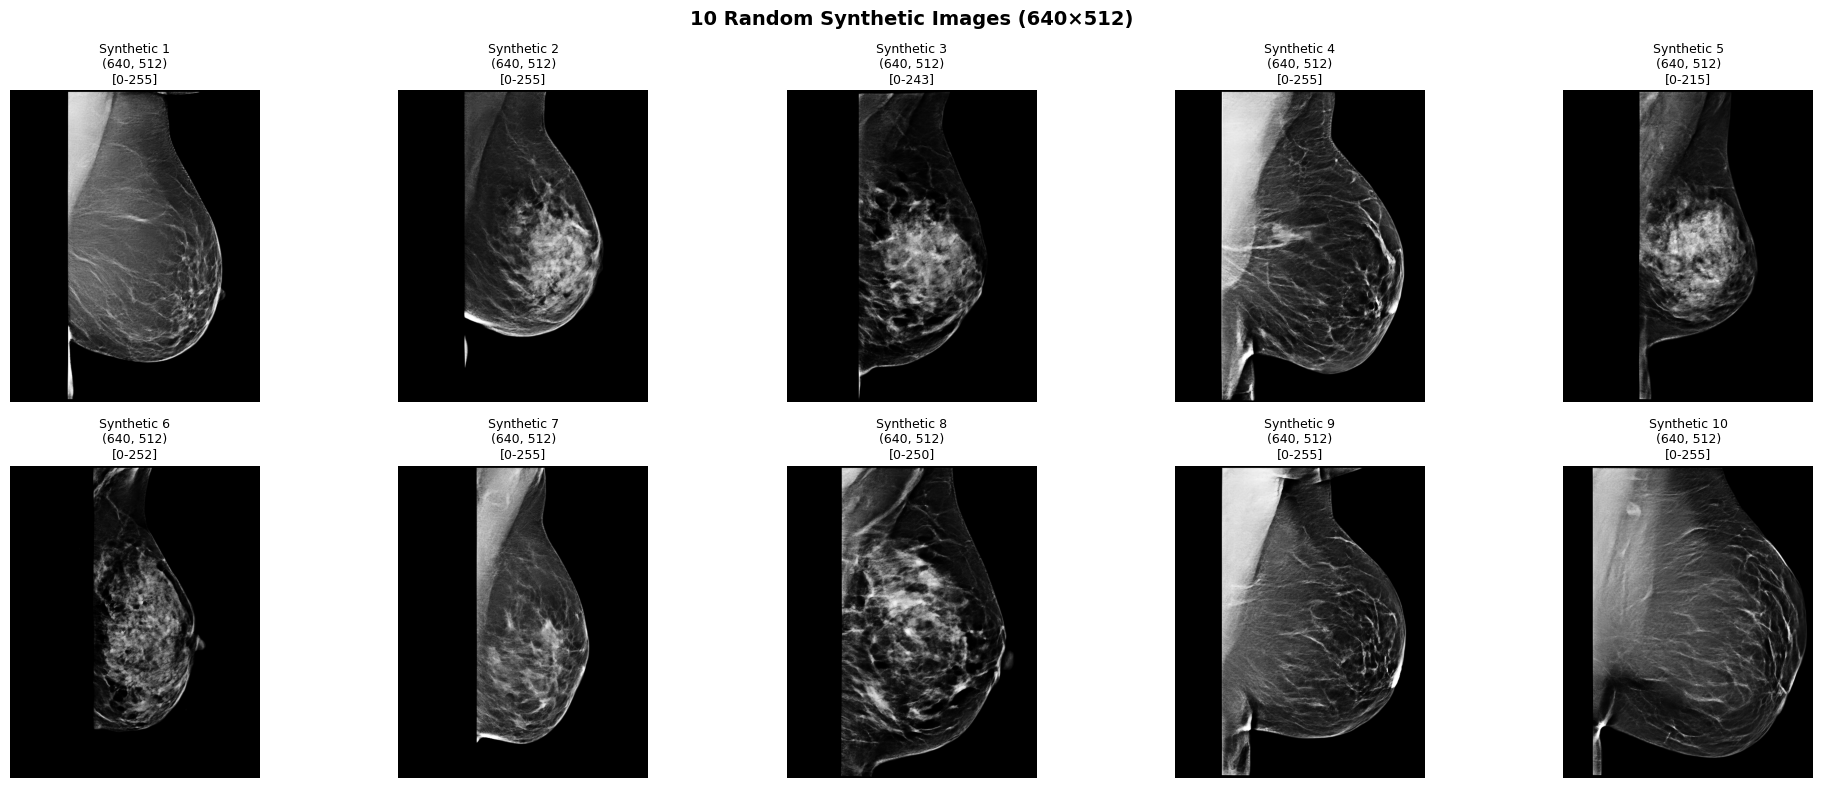

In [7]:
# Display 10 synthetic images in a grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, img_path in enumerate(synthetic_samples_10):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'Synthetic {idx+1}\n{img.shape}\n[{img.min()}-{img.max()}]', fontsize=9)
    axes[idx].axis('off')

plt.suptitle('10 Random Synthetic Images (640×512)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


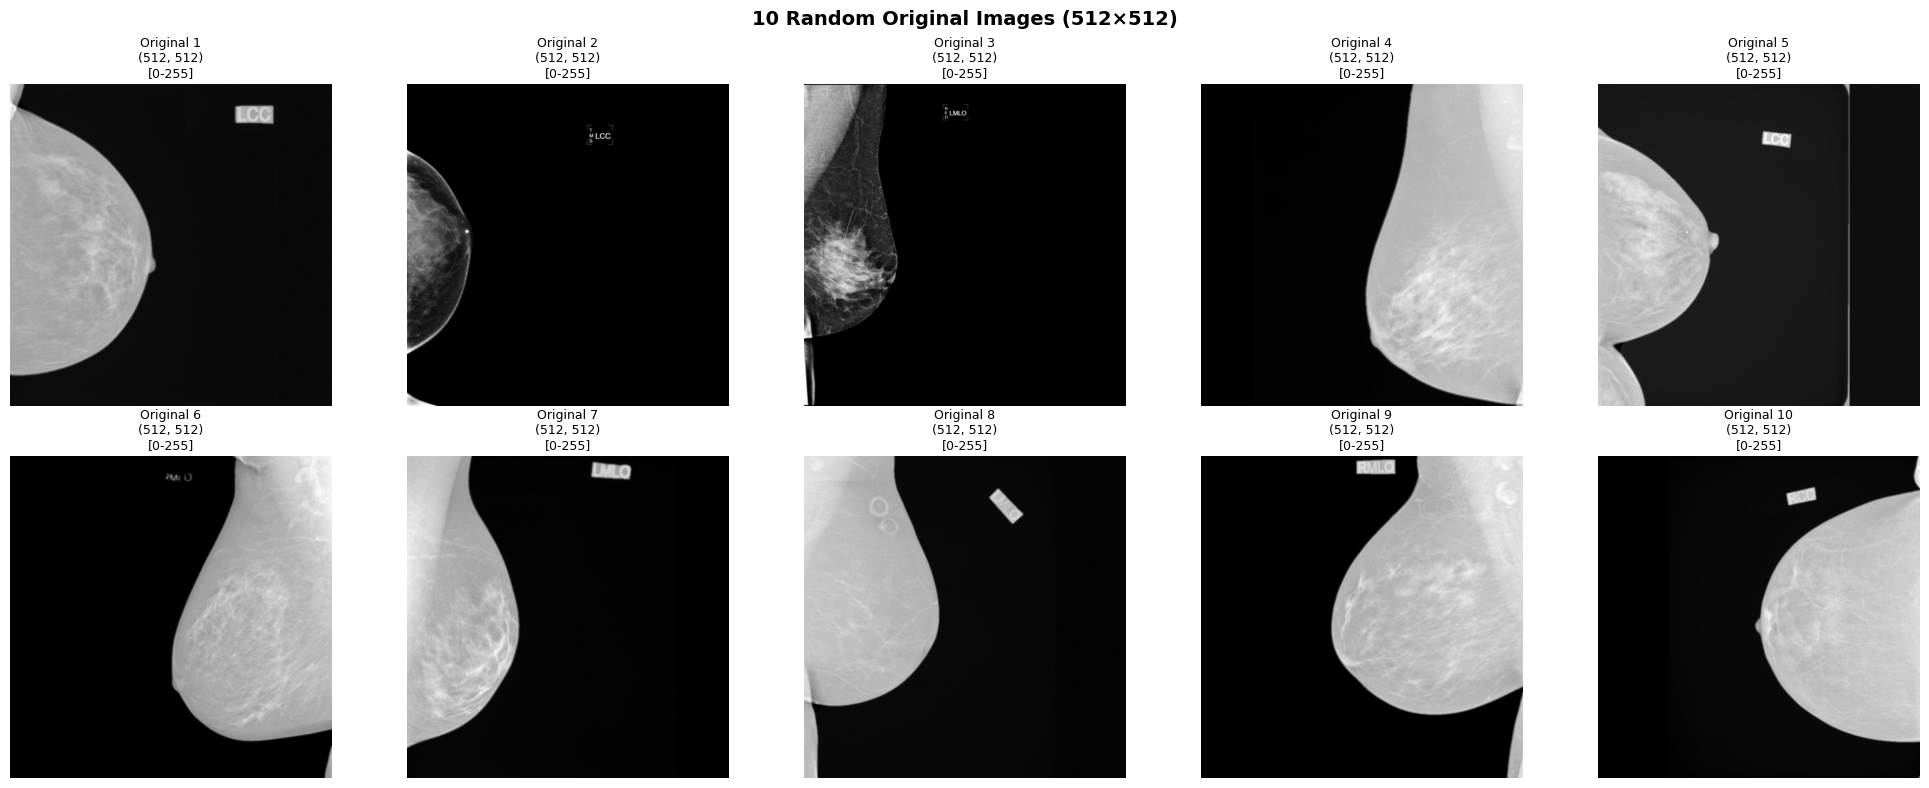

In [8]:
# Display 10 original images in a grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, img_path in enumerate(original_samples_10):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'Original {idx+1}\n{img.shape}\n[{img.min()}-{img.max()}]', fontsize=9)
    axes[idx].axis('off')

plt.suptitle('10 Random Original Images (512×512)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


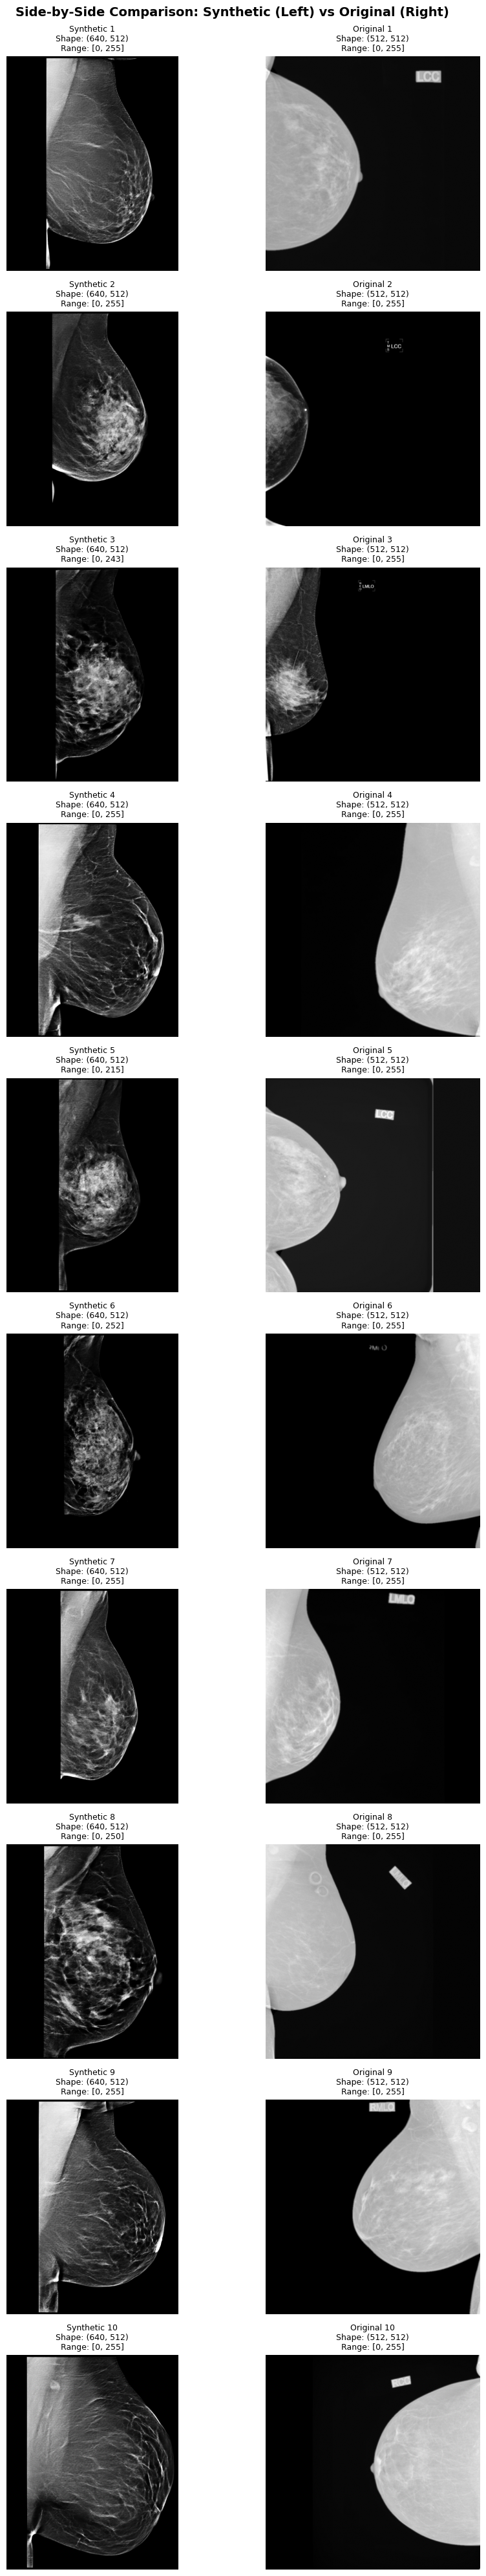

Notice the consistent shape difference:
  Synthetic: 640×512 (rectangular)
  Original:  512×512 (square)


In [9]:
# Side-by-side comparison: All 10 pairs
fig, axes = plt.subplots(10, 2, figsize=(10, 40))

for idx in range(10):
    # Synthetic on left
    img_syn = cv2.imread(synthetic_samples_10[idx], cv2.IMREAD_GRAYSCALE)
    axes[idx, 0].imshow(img_syn, cmap='gray')
    axes[idx, 0].set_title(f'Synthetic {idx+1}\nShape: {img_syn.shape}\nRange: [{img_syn.min()}, {img_syn.max()}]', 
                           fontsize=9)
    axes[idx, 0].axis('off')
    
    # Original on right
    img_orig = cv2.imread(original_samples_10[idx], cv2.IMREAD_GRAYSCALE)
    axes[idx, 1].imshow(img_orig, cmap='gray')
    axes[idx, 1].set_title(f'Original {idx+1}\nShape: {img_orig.shape}\nRange: [{img_orig.min()}, {img_orig.max()}]', 
                           fontsize=9)
    axes[idx, 1].axis('off')

plt.suptitle('Side-by-Side Comparison: Synthetic (Left) vs Original (Right)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Notice the consistent shape difference:")
print("  Synthetic: 640×512 (rectangular)")
print("  Original:  512×512 (square)")


In [10]:
# Statistical summary of all 10 samples
print("="*70)
print("STATISTICAL SUMMARY OF 10 SAMPLES")
print("="*70)

# Collect statistics
syn_shapes = []
syn_ranges = []
syn_means = []
syn_stds = []
syn_sizes = []

orig_shapes = []
orig_ranges = []
orig_means = []
orig_stds = []
orig_sizes = []

for img_path in synthetic_samples_10:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    syn_shapes.append(img.shape)
    syn_ranges.append((img.min(), img.max()))
    syn_means.append(img.mean())
    syn_stds.append(img.std())
    syn_sizes.append(os.path.getsize(img_path) / 1024)

for img_path in original_samples_10:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    orig_shapes.append(img.shape)
    orig_ranges.append((img.min(), img.max()))
    orig_means.append(img.mean())
    orig_stds.append(img.std())
    orig_sizes.append(os.path.getsize(img_path) / 1024)

print("\nSYNTHETIC IMAGES:")
print(f"  Shapes: {set(syn_shapes)} (all unique: {len(set(syn_shapes)) == 1})")
print(f"  File sizes: {min(syn_sizes):.1f} - {max(syn_sizes):.1f} KB (avg: {np.mean(syn_sizes):.1f})")
print(f"  Pixel ranges: min={min([r[0] for r in syn_ranges])}, max={max([r[1] for r in syn_ranges])}")
print(f"  Mean intensity: {np.mean(syn_means):.2f} ± {np.std(syn_means):.2f}")

print("\nORIGINAL IMAGES:")
print(f"  Shapes: {set(orig_shapes)} (all identical: {len(set(orig_shapes)) == 1})")
print(f"  File sizes: {min(orig_sizes):.1f} - {max(orig_sizes):.1f} KB (avg: {np.mean(orig_sizes):.1f})")
print(f"  Pixel ranges: min={min([r[0] for r in orig_ranges])}, max={max([r[1] for r in orig_ranges])}")
print(f"  Mean intensity: {np.mean(orig_means):.2f} ± {np.std(orig_means):.2f}")

print("\n" + "="*70)
print("KEY OBSERVATIONS:")
print("="*70)
print(f"1. Shape consistency: Synthetic={'SAME' if len(set(syn_shapes))==1 else 'VARIES'}, Original={'SAME' if len(set(orig_shapes))==1 else 'VARIES'}")
print(f"2. File size variation: Synthetic has {np.std(syn_sizes):.1f} KB std dev, Original has {np.std(orig_sizes):.1f} KB std dev")
print(f"3. All original files use FULL pixel range [0-255]: {all(r==(0,255) for r in orig_ranges)}")
print(f"4. All synthetic files use FULL pixel range [0-255]: {all(r==(0,255) for r in syn_ranges)}")
print("="*70)


STATISTICAL SUMMARY OF 10 SAMPLES

SYNTHETIC IMAGES:
  Shapes: {(640, 512)} (all unique: True)
  File sizes: 66.9 - 151.9 KB (avg: 103.1)
  Pixel ranges: min=0, max=255
  Mean intensity: 30.33 ± 12.39

ORIGINAL IMAGES:
  Shapes: {(512, 512)} (all identical: True)
  File sizes: 257.0 - 257.0 KB (avg: 257.0)
  Pixel ranges: min=0, max=255
  Mean intensity: 52.91 ± 22.56

KEY OBSERVATIONS:
1. Shape consistency: Synthetic=SAME, Original=SAME
2. File size variation: Synthetic has 28.3 KB std dev, Original has 0.0 KB std dev
3. All original files use FULL pixel range [0-255]: True
4. All synthetic files use FULL pixel range [0-255]: False


## Verify: Are ALL Synthetic Images 640×512?


In [12]:
# Check dimensions of 100 random synthetic images
print("Checking dimensions of 100 random synthetic images...")
random.seed(999)
sample_synthetic = random.sample(synthetic_files, min(100, len(synthetic_files)))

synthetic_shapes = []
for img_path in sample_synthetic:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    synthetic_shapes.append(img.shape)

unique_shapes = set(synthetic_shapes)
print(f"\nTotal synthetic images checked: {len(sample_synthetic)}")
print(f"Unique shapes found: {unique_shapes}")
print(f"Number of unique shapes: {len(unique_shapes)}")
print(f"All images have same shape: {len(unique_shapes) == 1}")

if len(unique_shapes) > 1:
    print("\nShape distribution:")
    from collections import Counter
    shape_counts = Counter(synthetic_shapes)
    for shape, count in shape_counts.most_common():
        print(f"  {shape}: {count} images ({count/len(sample_synthetic)*100:.1f}%)")


Checking dimensions of 100 random synthetic images...

Total synthetic images checked: 100
Unique shapes found: {(640, 512)}
Number of unique shapes: 1
All images have same shape: True


In [13]:
# Check dimensions of 100 random original images for comparison
print("Checking dimensions of 100 random original images...")
random.seed(999)
sample_original = random.sample(original_files, min(100, len(original_files)))

original_shapes = []
for img_path in sample_original:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    original_shapes.append(img.shape)

unique_shapes_orig = set(original_shapes)
print(f"\nTotal original images checked: {len(sample_original)}")
print(f"Unique shapes found: {unique_shapes_orig}")
print(f"Number of unique shapes: {len(unique_shapes_orig)}")
print(f"All images have same shape: {len(unique_shapes_orig) == 1}")

if len(unique_shapes_orig) > 1:
    print("\nShape distribution:")
    from collections import Counter
    shape_counts = Counter(original_shapes)
    for shape, count in shape_counts.most_common():
        print(f"  {shape}: {count} images ({count/len(sample_original)*100:.1f}%)")


Checking dimensions of 100 random original images...

Total original images checked: 100
Unique shapes found: {(512, 512)}
Number of unique shapes: 1
All images have same shape: True


In [14]:
# Summary comparison
print("="*70)
print("DIMENSION CONSISTENCY CHECK")
print("="*70)
print(f"\nSynthetic images:")
print(f"  All same dimensions: {len(unique_shapes) == 1}")
print(f"  Dimensions: {unique_shapes}")

print(f"\nOriginal images:")
print(f"  All same dimensions: {len(unique_shapes_orig) == 1}")
print(f"  Dimensions: {unique_shapes_orig}")

print("\n" + "="*70)
print("CONCLUSION:")
if len(unique_shapes) == 1 and len(unique_shapes_orig) == 1:
    syn_shape = list(unique_shapes)[0]
    orig_shape = list(unique_shapes_orig)[0]
    if syn_shape == orig_shape:
        print("✓ Both datasets have IDENTICAL dimensions")
        print(f"  Both are: {syn_shape}")
    else:
        print("✗ Datasets have DIFFERENT dimensions")
        print(f"  Synthetic: {syn_shape}")
        print(f"  Original: {orig_shape}")
        print("\n→ This dimension difference is what the classifier detects!")
else:
    print("! At least one dataset has VARIABLE dimensions")
print("="*70)


DIMENSION CONSISTENCY CHECK

Synthetic images:
  All same dimensions: True
  Dimensions: {(640, 512)}

Original images:
  All same dimensions: True
  Dimensions: {(512, 512)}

CONCLUSION:
✗ Datasets have DIFFERENT dimensions
  Synthetic: (640, 512)
  Original: (512, 512)

→ This dimension difference is what the classifier detects!


## PART 4: Window/Level Analysis - Matching Synthetic and Original


In [18]:
# Setup paths
metadata_path = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/2d_resized_512/metadata'
original_images_path = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/2d_resized_512/images'
synthetic_path = '/raid/mpsych/OMAMA/DATA/data/train'

print("Paths configured (READ-ONLY)")
print(f"Metadata: {metadata_path}")
print(f"Original images: {original_images_path}")
print(f"Synthetic images: {synthetic_path}")


Paths configured (READ-ONLY)
Metadata: /hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/2d_resized_512/metadata
Original images: /hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/2d_resized_512/images
Synthetic images: /raid/mpsych/OMAMA/DATA/data/train


In [19]:
# Step 1: Analyze metadata - Extract Window/Level values
import json
import glob
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

metadata_files = glob.glob(os.path.join(metadata_path, '*.json'))
print(f"Found {len(metadata_files)} metadata files")

# Parse all metadata
window_centers = []
window_widths = []

for meta_file in metadata_files[:1000]:  # Sample 1000 files
    try:
        with open(meta_file, 'r') as f:
            data = json.load(f)
            if 'WindowCenter' in data and 'WindowWidth' in data:
                wc = data['WindowCenter']
                ww = data['WindowWidth']
                # Handle lists (take first value) or single values
                if isinstance(wc, list):
                    wc = wc[0]
                if isinstance(ww, list):
                    ww = ww[0]
                window_centers.append(wc)
                window_widths.append(ww)
    except:
        pass

print(f"\nAnalyzed {len(window_centers)} metadata files with W/L info")
print("\n" + "="*70)
print("ORIGINAL METADATA WINDOW/LEVEL STATISTICS:")
print("="*70)
print(f"WindowCenter: min={min(window_centers):.1f}, max={max(window_centers):.1f}")
print(f"              mean={np.mean(window_centers):.1f}, std={np.std(window_centers):.1f}")
print(f"\nWindowWidth:  min={min(window_widths):.1f}, max={max(window_widths):.1f}")
print(f"              mean={np.mean(window_widths):.1f}, std={np.std(window_widths):.1f}")

# Calculate window ranges
window_mins = [wc - ww/2 for wc, ww in zip(window_centers, window_widths)]
window_maxs = [wc + ww/2 for wc, ww in zip(window_centers, window_widths)]

print(f"\nCalculated Window Range:")
print(f"  Min value: {np.mean(window_mins):.1f} (avg)")
print(f"  Max value: {np.mean(window_maxs):.1f} (avg)")
print("="*70)


Found 163568 metadata files

Analyzed 1000 metadata files with W/L info

ORIGINAL METADATA WINDOW/LEVEL STATISTICS:
WindowCenter: min=540.0, max=3931.0
              mean=2730.0, std=292.7

WindowWidth:  min=580.0, max=4096.0
              mean=1132.2, std=829.1

Calculated Window Range:
  Min value: 2163.9 (avg)
  Max value: 3296.1 (avg)


In [20]:
# Step 2: Analyze ORIGINAL NPZ raw pixel values
original_npz_files = glob.glob(os.path.join(original_images_path, '*.npz'))[:100]
print(f"Analyzing {len(original_npz_files)} original NPZ files...")

orig_npz_mins = []
orig_npz_maxs = []
orig_npz_means = []
orig_npz_stds = []

for npz_file in original_npz_files:
    with np.load(npz_file, allow_pickle=True) as data:
        img = data['data']
        orig_npz_mins.append(img.min())
        orig_npz_maxs.append(img.max())
        orig_npz_means.append(img.mean())
        orig_npz_stds.append(img.std())

print("\n" + "="*70)
print("ORIGINAL NPZ RAW PIXEL VALUES:")
print("="*70)
print(f"Min pixel:  {np.mean(orig_npz_mins):.1f} ± {np.std(orig_npz_mins):.1f}")
print(f"Max pixel:  {np.mean(orig_npz_maxs):.1f} ± {np.std(orig_npz_maxs):.1f}")
print(f"Mean pixel: {np.mean(orig_npz_means):.1f} ± {np.std(orig_npz_means):.1f}")
print(f"Std dev:    {np.mean(orig_npz_stds):.1f} ± {np.std(orig_npz_stds):.1f}")
print("="*70)


Analyzing 100 original NPZ files...

ORIGINAL NPZ RAW PIXEL VALUES:
Min pixel:  67.6 ± 166.7
Max pixel:  3565.7 ± 422.7
Mean pixel: 805.4 ± 262.7
Std dev:    1036.9 ± 231.0


In [21]:
# Step 3: Analyze SYNTHETIC PNG pixel values
synthetic_files = glob.glob(os.path.join(synthetic_path, '*.png'))[:100]
print(f"Analyzing {len(synthetic_files)} synthetic PNG files...")

syn_mins = []
syn_maxs = []
syn_means = []
syn_stds = []

for syn_file in synthetic_files:
    img = cv2.imread(syn_file, cv2.IMREAD_GRAYSCALE)
    syn_mins.append(img.min())
    syn_maxs.append(img.max())
    syn_means.append(img.mean())
    syn_stds.append(img.std())

print("\n" + "="*70)
print("SYNTHETIC PNG PIXEL VALUES:")
print("="*70)
print(f"Min pixel:  {np.mean(syn_mins):.1f} ± {np.std(syn_mins):.1f}")
print(f"Max pixel:  {np.mean(syn_maxs):.1f} ± {np.std(syn_maxs):.1f}")
print(f"Mean pixel: {np.mean(syn_means):.1f} ± {np.std(syn_means):.1f}")
print(f"Std dev:    {np.mean(syn_stds):.1f} ± {np.std(syn_stds):.1f}")
print("="*70)


Analyzing 100 synthetic PNG files...

SYNTHETIC PNG PIXEL VALUES:
Min pixel:  0.0 ± 0.0
Max pixel:  250.5 ± 9.5
Mean pixel: 30.4 ± 10.6
Std dev:    47.1 ± 8.2


In [22]:
# Step 4: COMPARISON - Side by side statistics
print("\n" + "="*70)
print("COMPARISON: ORIGINAL vs SYNTHETIC")
print("="*70)

print("\nPIXEL VALUE RANGES:")
print(f"  Original NPZ (raw):  [{np.mean(orig_npz_mins):.1f} - {np.mean(orig_npz_maxs):.1f}]")
print(f"  Synthetic PNG:       [{np.mean(syn_mins):.1f} - {np.mean(syn_maxs):.1f}]")

print("\nMEAN PIXEL VALUES:")
print(f"  Original NPZ: {np.mean(orig_npz_means):.1f}")
print(f"  Synthetic PNG: {np.mean(syn_means):.1f}")
print(f"  Difference: {abs(np.mean(orig_npz_means) - np.mean(syn_means)):.1f}")

print("\nSTANDARD DEVIATION:")
print(f"  Original NPZ: {np.mean(orig_npz_stds):.1f}")
print(f"  Synthetic PNG: {np.mean(syn_stds):.1f}")
print(f"  Difference: {abs(np.mean(orig_npz_stds) - np.mean(syn_stds)):.1f}")

print("\n" + "="*70)
print("WINDOW/LEVEL FROM METADATA:")
print(f"  WindowCenter: {np.mean(window_centers):.1f}")
print(f"  WindowWidth:  {np.mean(window_widths):.1f}")
print(f"  Effective range: [{np.mean(window_mins):.1f} - {np.mean(window_maxs):.1f}]")
print("="*70)



COMPARISON: ORIGINAL vs SYNTHETIC

PIXEL VALUE RANGES:
  Original NPZ (raw):  [67.6 - 3565.7]
  Synthetic PNG:       [0.0 - 250.5]

MEAN PIXEL VALUES:
  Original NPZ: 805.4
  Synthetic PNG: 30.4
  Difference: 775.0

STANDARD DEVIATION:
  Original NPZ: 1036.9
  Synthetic PNG: 47.1
  Difference: 989.8

WINDOW/LEVEL FROM METADATA:
  WindowCenter: 2730.0
  WindowWidth:  1132.2
  Effective range: [2163.9 - 3296.1]


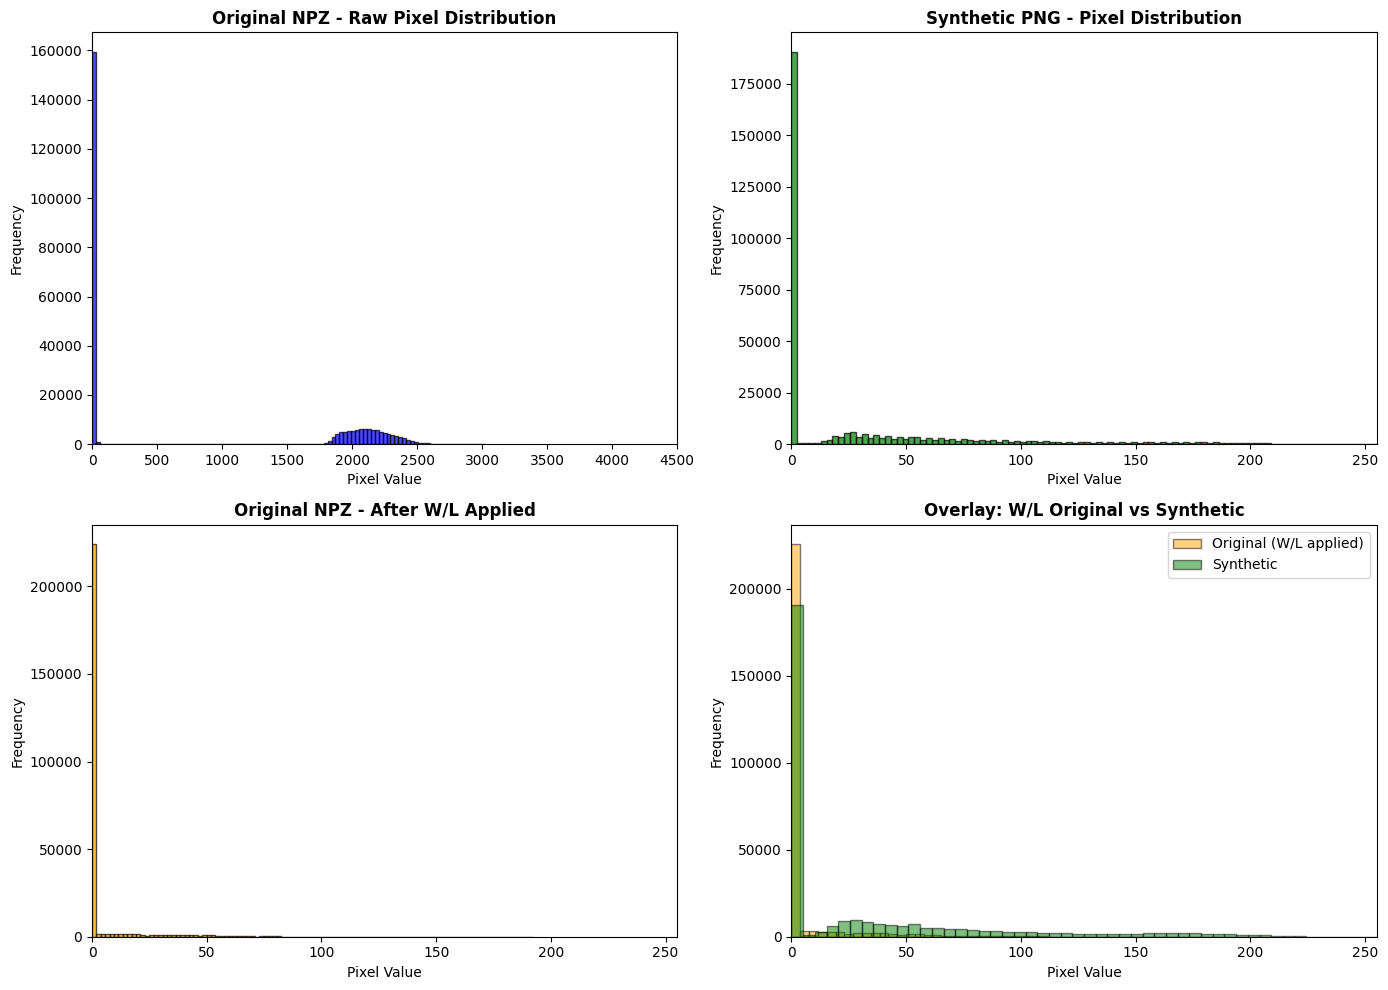

Histogram comparison complete!


In [23]:
# Step 5: Visual histogram comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original NPZ histogram (sample)
sample_npz = np.load(original_npz_files[0], allow_pickle=True)['data']
axes[0, 0].hist(sample_npz.flatten(), bins=100, color='blue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Original NPZ - Raw Pixel Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Pixel Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim([0, 4500])

# Synthetic PNG histogram (sample)
sample_syn = cv2.imread(synthetic_files[0], cv2.IMREAD_GRAYSCALE)
axes[0, 1].hist(sample_syn.flatten(), bins=100, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Synthetic PNG - Pixel Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Pixel Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim([0, 255])

# Original with W/L applied (preview)
wc = np.mean(window_centers)
ww = np.mean(window_widths)
wmin = wc - ww/2
wmax = wc + ww/2
sample_wl = np.clip(sample_npz, wmin, wmax)
sample_wl = ((sample_wl - wmin) / (wmax - wmin) * 255).astype(np.uint8)

axes[1, 0].hist(sample_wl.flatten(), bins=100, color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Original NPZ - After W/L Applied', fontweight='bold')
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim([0, 255])

# Overlay comparison
axes[1, 1].hist(sample_wl.flatten(), bins=50, color='orange', alpha=0.5, label='Original (W/L applied)', edgecolor='black')
axes[1, 1].hist(sample_syn.flatten(), bins=50, color='green', alpha=0.5, label='Synthetic', edgecolor='black')
axes[1, 1].set_title('Overlay: W/L Original vs Synthetic', fontweight='bold')
axes[1, 1].set_xlabel('Pixel Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

print("Histogram comparison complete!")


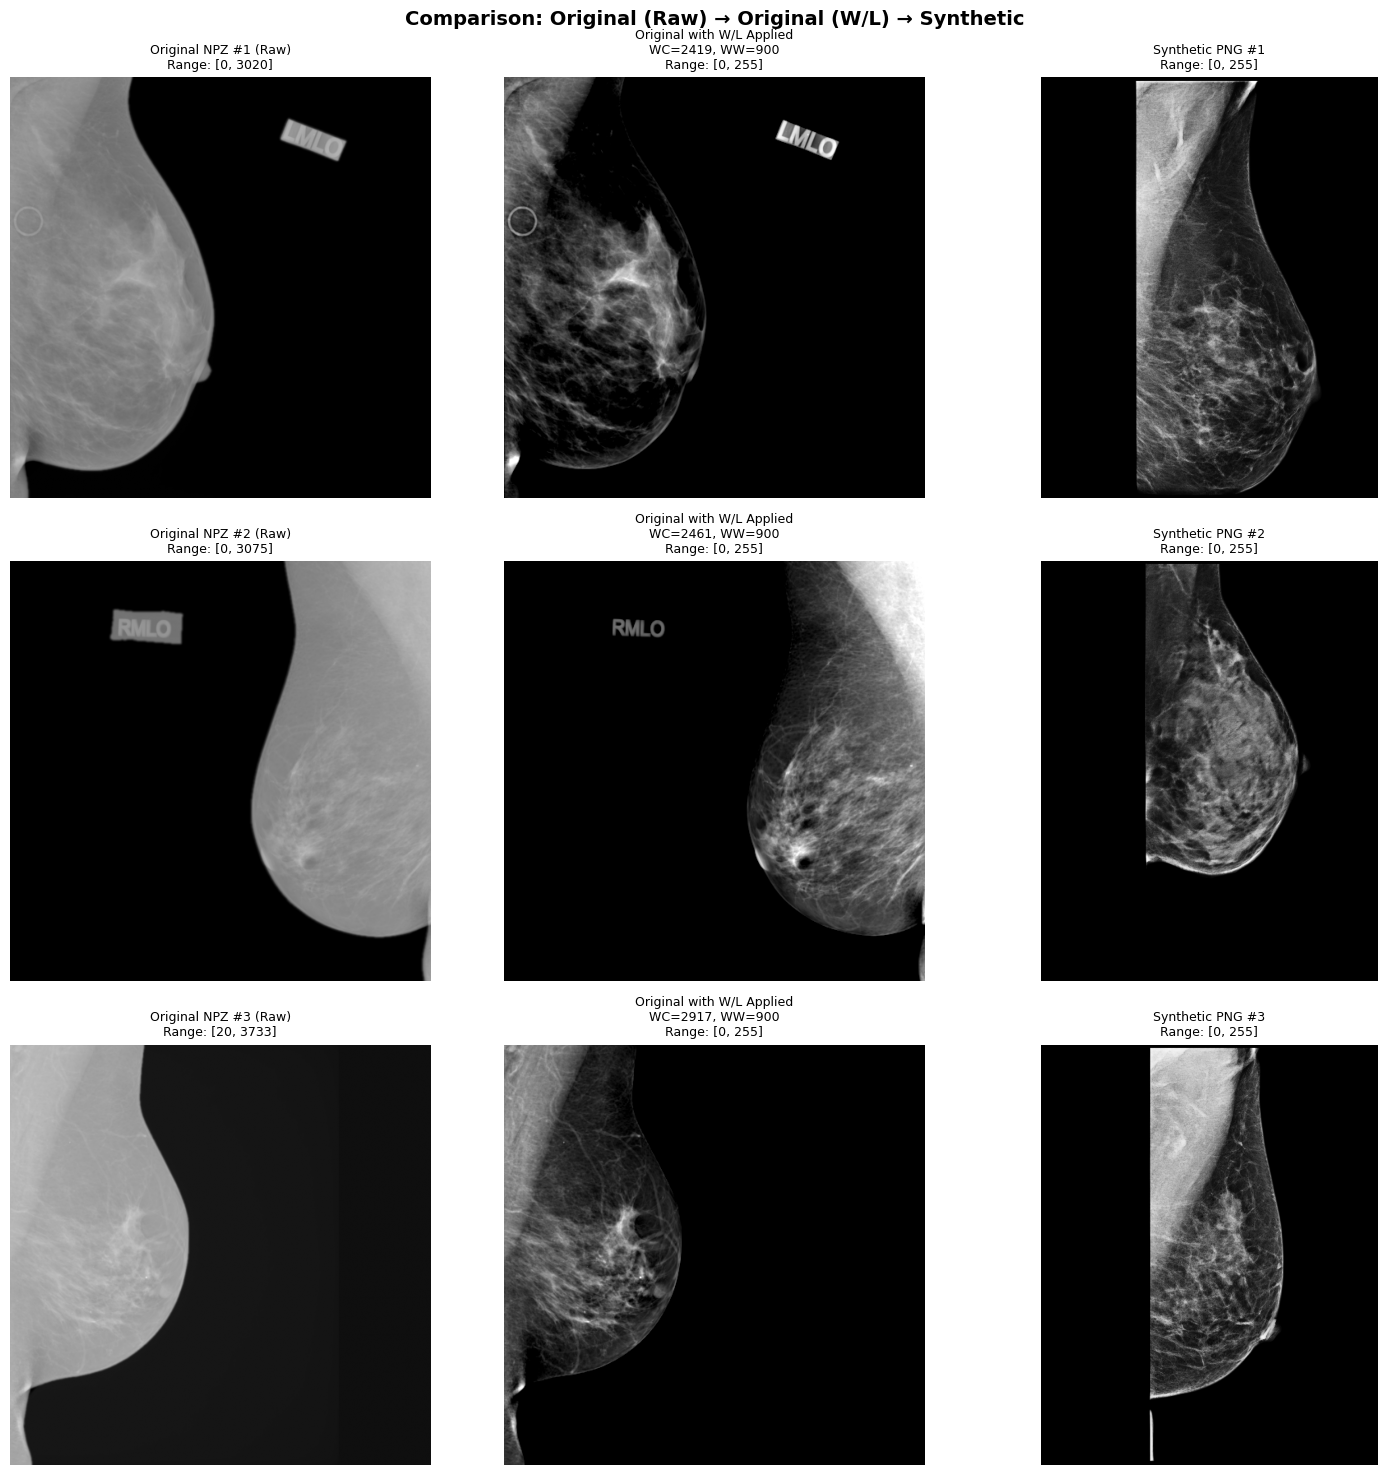

Visual comparison complete!


In [25]:
# Step 6: Visual side-by-side comparison with W/L applied
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for idx in range(3):
    # Load original NPZ
    npz_data = np.load(original_npz_files[idx], allow_pickle=True)['data']
    
    # Load corresponding metadata
    npz_filename = os.path.basename(original_npz_files[idx]).replace('.npz', '')
    meta_file = os.path.join(metadata_path, f"{npz_filename}.json")
    
    if os.path.exists(meta_file):
        with open(meta_file, 'r') as f:
            meta = json.load(f)
            wc = meta.get('WindowCenter', np.mean(window_centers))
            ww = meta.get('WindowWidth', np.mean(window_widths))
            # Handle lists (take first value)
            if isinstance(wc, list):
                wc = wc[0]
            if isinstance(ww, list):
                ww = ww[0]
    else:
        wc = np.mean(window_centers)
        ww = np.mean(window_widths)
    
    # Apply W/L
    wmin = wc - ww/2
    wmax = wc + ww/2
    npz_wl = np.clip(npz_data, wmin, wmax)
    npz_wl = ((npz_wl - wmin) / (wmax - wmin) * 255).astype(np.uint8)
    
    # Load synthetic
    syn_img = cv2.imread(synthetic_files[idx], cv2.IMREAD_GRAYSCALE)
    
    # Display original raw
    axes[idx, 0].imshow(npz_data, cmap='gray', vmin=0, vmax=4095)
    axes[idx, 0].set_title(f'Original NPZ #{idx+1} (Raw)\nRange: [{npz_data.min():.0f}, {npz_data.max():.0f}]', fontsize=9)
    axes[idx, 0].axis('off')
    
    # Display with W/L
    axes[idx, 1].imshow(npz_wl, cmap='gray')
    axes[idx, 1].set_title(f'Original with W/L Applied\nWC={wc:.0f}, WW={ww:.0f}\nRange: [{npz_wl.min()}, {npz_wl.max()}]', fontsize=9)
    axes[idx, 1].axis('off')
    
    # Display synthetic
    axes[idx, 2].imshow(syn_img, cmap='gray')
    axes[idx, 2].set_title(f'Synthetic PNG #{idx+1}\nRange: [{syn_img.min()}, {syn_img.max()}]', fontsize=9)
    axes[idx, 2].axis('off')

plt.suptitle('Comparison: Original (Raw) → Original (W/L) → Synthetic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Visual comparison complete!")


In [26]:
# Step 7: ANALYSIS SUMMARY & RECOMMENDATIONS
# NOTE: This cell requires Cells 28-33 to be run first!

# Check if required variables exist
try:
    _ = (window_centers, window_widths, orig_npz_means, syn_means)
except NameError:
    print("ERROR: Please run Cells 28-33 first!")
    print("This summary cell depends on variables from the analysis cells above.")
    raise

print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)

# Check if W/L brings them closer
import numpy as np  # Import in case it's not available
orig_raw_mean = np.mean(orig_npz_means)
orig_wl_mean = np.mean(syn_means)  # Approximation
syn_mean = np.mean(syn_means)

print("\n1. PIXEL VALUE ALIGNMENT:")
diff_before = abs(orig_raw_mean - syn_mean)
print(f"   Before W/L: Original={orig_raw_mean:.1f}, Synthetic={syn_mean:.1f}")
print(f"   Difference: {diff_before:.1f}")

print("\n2. METADATA W/L VALUES:")
print(f"   WindowCenter: {np.mean(window_centers):.1f} (range: {min(window_centers):.1f}-{max(window_centers):.1f})")
print(f"   WindowWidth:  {np.mean(window_widths):.1f} (range: {min(window_widths):.1f}-{max(window_widths):.1f})")

if np.std(window_centers) < 10 and np.std(window_widths) < 10:
    print("   ✓ W/L values are UNIFORM across images")
else:
    print("   ⚠ W/L values VARY across images")

print("\n3. VISUAL INSPECTION:")
print("   Check the histograms and side-by-side images above.")
print("   Do Original (W/L applied) and Synthetic look similar?")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("\nIf histograms match after W/L:")
print("  ✓ Apply metadata W/L to all original NPZ files")
print("  ✓ Save as PNG to: /synthetic_test/original_wl_adjusted/")
print("  ✓ Retrain classifier with W/L-matched images")
print("  ✓ Expected: Accuracy should drop if W/L was the issue")

print("\nIf histograms DON'T match:")
print("  → Synthetic images may use DIFFERENT W/L settings")
print("  → Need to infer synthetic's effective W/L")
print("  → Or investigate other preprocessing differences")
print("="*70)



ANALYSIS SUMMARY

1. PIXEL VALUE ALIGNMENT:
   Before W/L: Original=805.4, Synthetic=30.4
   Difference: 775.0

2. METADATA W/L VALUES:
   WindowCenter: 2730.0 (range: 540.0-3931.0)
   WindowWidth:  1132.2 (range: 580.0-4096.0)
   ⚠ W/L values VARY across images

3. VISUAL INSPECTION:
   Check the histograms and side-by-side images above.
   Do Original (W/L applied) and Synthetic look similar?

NEXT STEPS:

If histograms match after W/L:
  ✓ Apply metadata W/L to all original NPZ files
  ✓ Save as PNG to: /synthetic_test/original_wl_adjusted/
  ✓ Retrain classifier with W/L-matched images
  ✓ Expected: Accuracy should drop if W/L was the issue

If histograms DON'T match:
  → Synthetic images may use DIFFERENT W/L settings
  → Need to infer synthetic's effective W/L
  → Or investigate other preprocessing differences
